In [31]:
# 导入数据处理库
import pandas as pd
import numpy as np

# 导入可视化库
import matplotlib.pyplot as plt
import seaborn as sns

# 导入模型和评估指标
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('train.csv')

# 查看数据前5行
print("数据前5行：")
print(df.head())

# 查看数据基本信息
print("\n数据基本信息：")
print(df.info())

# 查看目标变量分布
print("\n目标变量分布：")
print(df['target'].value_counts())
print(f"5G用户占比：{df['target'].mean():.2%}")

数据前5行：
   id  cat_0  cat_1  cat_2  cat_3  cat_4  cat_5  cat_6  cat_7  cat_8  ...  \
0   0      2    103      9      4      3      1      3      4      4  ...   
1   1      0    177      6      2      2      1      2      4      4  ...   
2   2      7     70      7      4      5      0      3      4      4  ...   
3   3     11    166      7      2      3      1      1      1      2  ...   
4   4      0    178     10      4      3      0      4      4      4  ...   

      num_29  num_30    num_31  num_32  num_33  num_34  num_35       num_36  \
0   2.000000     3.0  0.000000     0.0     0.0     0.0     0.0     0.089758   
1   0.968742     0.0  0.000000     0.0     0.0     0.0     0.0     0.000000   
2   0.000000     0.0  0.000000     0.0     0.0     0.0     0.0     0.000000   
3   0.021729     0.0  0.021729     0.0     0.0     0.0     0.0     0.000081   
4  30.000000    30.0  0.000000     0.0     0.0     0.0     0.0  6127.621124   

     num_37  target  
0  0.000129     0.0  
1  0.000312

In [2]:
# 1. 分离特征和目标变量
X = df.drop(['id', 'target'], axis=1)  # 去掉id和目标列，剩下的都是特征
y = df['target']  # 目标变量

# 2. 分离离散特征和数值特征
cat_features = [col for col in X.columns if col.startswith('cat_')]
num_features = [col for col in X.columns if col.startswith('num_')]

print(f"离散特征数量：{len(cat_features)}")
print(f"数值特征数量：{len(num_features)}")

# 3. 处理缺失值（LightGBM自动处理缺失值，这里只做最简单的填充）
# 离散特征用众数填充
for col in cat_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# 数值特征用中位数填充
for col in num_features:
    X[col] = X[col].fillna(X[col].median())

# 4. 划分训练集和测试集（7:3划分）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")

离散特征数量：20
数值特征数量：38

训练集大小：(560000, 58)
测试集大小：(240000, 58)


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 优化逻辑回归参数
lr_model = LogisticRegression(
    solver="saga",    # 收敛更稳定的优化器
    max_iter=10000,   # 大幅提高迭代上限
    C=0.5,            # 适度加强正则，避免参数爆炸
    random_state=42
)

# 3. 训练、预测、计算AUC
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)
print(f"逻辑回归模型AUC：{auc_lr:.4f}")

逻辑回归模型AUC：0.8352


In [4]:
# 1. 创建LightGBM模型（先用默认参数）
lgb_model = LGBMClassifier(random_state=42, verbose=-1)

# 2. 训练模型
lgb_model.fit(X_train, y_train)

# 3. 预测概率
y_pred_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 4. 计算AUC
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
print(f"LightGBM模型（默认参数）AUC：{auc_lgb:.4f}")

LightGBM模型（默认参数）AUC：0.9054


In [5]:
# 调整后的LightGBM模型
lgb_model_tuned = LGBMClassifier(
    n_estimators=200,  # 树的数量
    max_depth=5,       # 树的最大深度
    learning_rate=0.1, # 学习率
    subsample=0.8,     # 每次训练用80%的样本
    colsample_bytree=0.8, # 每次训练用80%的特征
    random_state=42,
    verbose=-1
)

# 训练调优后的模型
lgb_model_tuned.fit(X_train, y_train)

# 预测概率
y_pred_lgb_tuned = lgb_model_tuned.predict_proba(X_test)[:, 1]

# 计算AUC
auc_lgb_tuned = roc_auc_score(y_test, y_pred_lgb_tuned)
print(f"LightGBM模型（调优后）AUC：{auc_lgb_tuned:.4f}")

LightGBM模型（调优后）AUC：0.9128


模型性能对比：
             模型       AUC
0          逻辑回归  0.835234
1  LightGBM(默认)  0.905423
2  LightGBM(调优)  0.912767


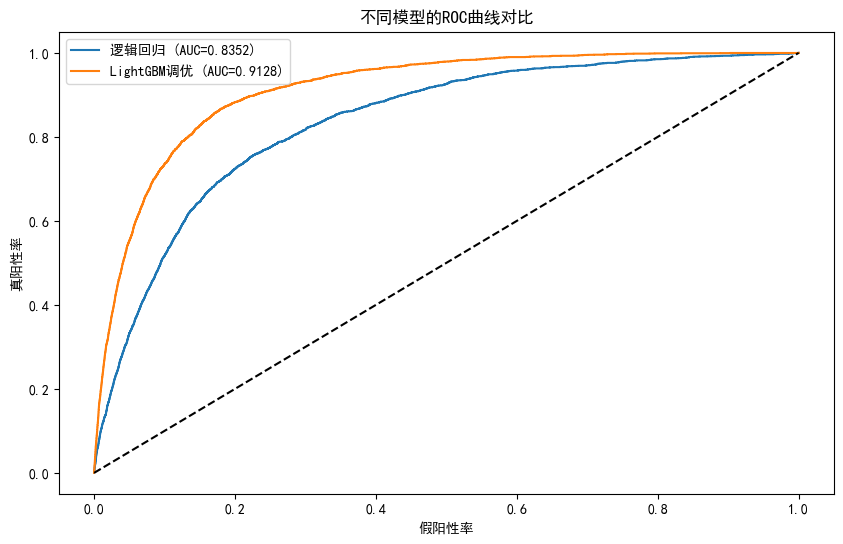

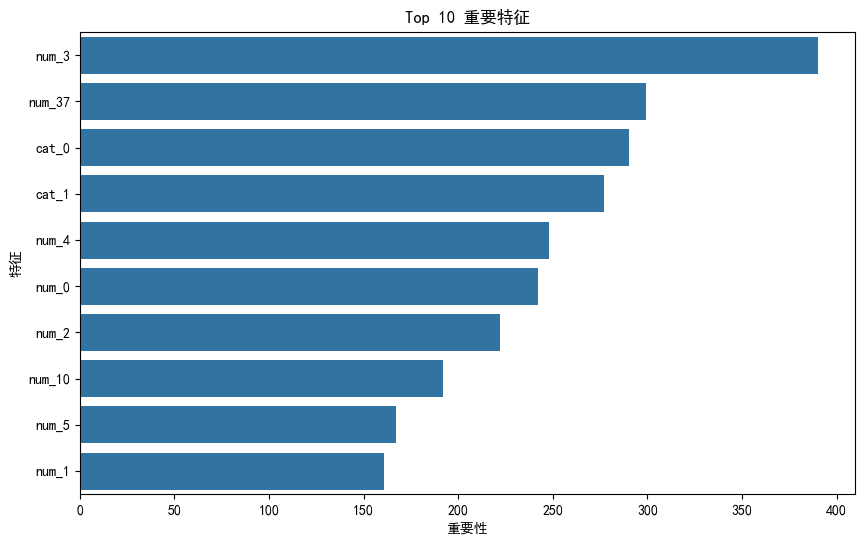

In [6]:
# 1. 模型性能对比表
results = pd.DataFrame({
    '模型': ['逻辑回归', 'LightGBM(默认)', 'LightGBM(调优)'],
    'AUC': [auc_lr, auc_lgb, auc_lgb_tuned]
})
print("模型性能对比：")
print(results)

# 2. 绘制ROC曲线
plt.figure(figsize=(10, 6))

# 逻辑回归ROC曲线
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
plt.plot(fpr_lr, tpr_lr, label=f'逻辑回归 (AUC={auc_lr:.4f})')

# 调优后LightGBM ROC曲线
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_lgb_tuned)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM调优 (AUC={auc_lgb_tuned:.4f})')

# 对角线
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('假阳性率')
plt.ylabel('真阳性率')
plt.title('不同模型的ROC曲线对比')
plt.legend()
plt.savefig('roc曲线.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. 绘制特征重要性（LightGBM）
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': lgb_model_tuned.feature_importances_
}).sort_values('重要性', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='重要性', y='特征', data=feature_importance)
plt.title('Top 10 重要特征')
plt.savefig('特征重要性.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import joblib

# 保存调优后的LightGBM模型
joblib.dump(lgb_model_tuned, 'lgb_model_tuned.pkl')

print("模型已保存为 lgb_model_tuned.pkl")

模型已保存为 lgb_model_tuned.pkl


In [7]:
# 计算正负样本比例
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"正负样本比例：{pos_weight:.2f}:1")

# 带权重的LightGBM模型
lgb_model_weighted = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,  # 关键参数：平衡正负样本权重
    random_state=42,
    verbose=-1
)

# 训练并评估
lgb_model_weighted.fit(X_train, y_train)
y_pred_weighted = lgb_model_weighted.predict_proba(X_test)[:, 1]
auc_weighted = roc_auc_score(y_test, y_pred_weighted)
print(f"调整类权重后AUC：{auc_weighted:.4f}")
print(f"相比调优前提升：{auc_weighted - auc_lgb_tuned:.4f}")

正负样本比例：74.47:1
调整类权重后AUC：0.9036
相比调优前提升：-0.0091


In [8]:
from imblearn.over_sampling import SMOTE

# 初始化SMOTE
smote = SMOTE(random_state=42)

# 对训练集进行过采样（注意：只能对训练集做，绝对不能对测试集做！）
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"过采样前训练集大小：{X_train.shape}")
print(f"过采样后训练集大小：{X_train_smote.shape}")
print(f"过采样后5G用户占比：{y_train_smote.mean():.2%}")

# 用过采样后的数据训练模型
lgb_model_smote = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lgb_model_smote.predict_proba(X_test)[:, 1]
auc_smote = roc_auc_score(y_test, y_pred_smote)
print(f"SMOTE过采样后AUC：{auc_smote:.4f}")

过采样前训练集大小：(560000, 58)
过采样后训练集大小：(1105160, 58)
过采样后5G用户占比：50.00%
SMOTE过采样后AUC：0.8280


In [9]:
from imblearn.under_sampling import RandomUnderSampler

# 初始化随机欠采样器
rus = RandomUnderSampler(random_state=42)

# 对训练集进行欠采样
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"欠采样前训练集大小：{X_train.shape}")
print(f"欠采样后训练集大小：{X_train_rus.shape}")
print(f"欠采样后5G用户占比：{y_train_rus.mean():.2%}")

# 训练模型
lgb_model_rus = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = lgb_model_rus.predict_proba(X_test)[:, 1]
auc_rus = roc_auc_score(y_test, y_pred_rus)
print(f"随机欠采样后AUC：{auc_rus:.4f}")

欠采样前训练集大小：(560000, 58)
欠采样后训练集大小：(14840, 58)
欠采样后5G用户占比：50.00%
随机欠采样后AUC：0.9086


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# 复制一份特征数据用于特征工程
X_fe = X.copy()

# 筛选数值特征
num_features = [col for col in X_fe.columns if col.startswith('num_')]

# 新建字典存放所有衍生特征，循环里不修改原df
new_cols = {}
for col in num_features:
    new_cols[f'{col}_log'] = np.log1p(X_fe[col])
    new_cols[f'{col}_square'] = X_fe[col] ** 2
    new_cols[f'{col}_sqrt'] = np.sqrt(X_fe[col])

# 一次性拼接所有新列，只操作一次内存，不会碎片化
X_fe = pd.concat([X_fe, pd.DataFrame(new_cols)], axis=1)

# 重新划分训练集和测试集
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.3, random_state=42, stratify=y
)

# 训练模型看效果
lgb_model_fe = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = lgb_model_fe.predict_proba(X_test_fe)[:, 1]
auc_fe = roc_auc_score(y_test_fe, y_pred_fe)
print(f"添加统计变换特征后AUC：{auc_fe:.4f}")

添加统计变换特征后AUC：0.9125


In [ ]:
# 离散特征之间的交叉
for i in range(5):  # 只选前5个离散特征做交叉，避免特征爆炸
    for j in range(i+1, 5):
        X_fe[f'cat_{i}_x_cat_{j}'] = X_fe[f'cat_{i}'].astype(str) + '_' + X_fe[f'cat_{j}'].astype(str)
        # 对交叉后的特征进行标签编码
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        X_fe[f'cat_{i}_x_cat_{j}'] = le.fit_transform(X_fe[f'cat_{i}_x_cat_{j}'])

# 数值特征之间的交叉
for i in range(5):  # 只选前5个数值特征做交叉
    for j in range(i+1, 5):
        # 比值
        X_fe[f'num_{i}_div_num_{j}'] = X_fe[f'num_{i}'] / (X_fe[f'num_{j}'] + 1e-6)  # 加小值避免除0
        # 差值
        X_fe[f'num_{i}_sub_num_{j}'] = X_fe[f'num_{i}'] - X_fe[f'num_{j}']

# 重新划分训练集和测试集并训练模型（同上）
# 重新划分训练集和测试集
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.3, random_state=42, stratify=y
)

# 训练模型看效果
lgb_model_fe = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = lgb_model_fe.predict_proba(X_test_fe)[:, 1]
auc_fe = roc_auc_score(y_test_fe, y_pred_fe)
print(f"添加特征交叉后AUC：{auc_fe:.4f}")

In [ ]:
# 按每个离散特征分组，计算数值特征的均值和标准差
for cat_col in cat_features[:5]:  # 只选前5个离散特征
    for num_col in num_features[:5]:  # 只选前5个数值特征
        # 计算分组均值
        group_mean = X_fe.groupby(cat_col)[num_col].mean().reset_index()
        group_mean.columns = [cat_col, f'{cat_col}_{num_col}_mean']
        
        # 合并回原数据
        X_fe = X_fe.merge(group_mean, on=cat_col, how='left')
        
        # 计算分组标准差
        group_std = X_fe.groupby(cat_col)[num_col].std().reset_index()
        group_std.columns = [cat_col, f'{cat_col}_{num_col}_std']
        
        # 合并回原数据
        X_fe = X_fe.merge(group_std, on=cat_col, how='left')

# 填充新特征的缺失值
X_fe = X_fe.fillna(0)

# 重新划分训练集和测试集并训练模型
# 重新划分训练集和测试集
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.3, random_state=42, stratify=y
)

# 训练模型看效果
lgb_model_fe = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = lgb_model_fe.predict_proba(X_test_fe)[:, 1]
auc_fe = roc_auc_score(y_test_fe, y_pred_fe)
print(f"添加分组统计特征后AUC：{auc_fe:.4f}")

In [19]:
# 先训练一个模型得到特征重要性
lgb_model_for_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model_for_fs.fit(X_train_fe, y_train_fe)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': lgb_model_for_fs.feature_importances_
}).sort_values('importance', ascending=False)

# 只保留重要性前N个特征（比如前50个）
top_n = 30
top_features = feature_importance.head(top_n)['feature'].tolist()

# 筛选特征
X_train_fs = X_train_fe[top_features]
X_test_fs = X_test_fe[top_features]

print(f"特征选择前数量：{X_train_fe.shape[1]}")
print(f"特征选择后数量：{X_train_fs.shape[1]}")

# 训练模型看效果
lgb_model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fs.fit(X_train_fs, y_train_fe)
y_pred_fs = lgb_model_fs.predict_proba(X_test_fs)[:, 1]
auc_fs = roc_auc_score(y_test_fe, y_pred_fs)
print(f"特征选择后AUC：{auc_fs:.4f}")

特征选择前数量：302
特征选择后数量：30
特征选择后AUC：0.9054


In [20]:
# 先训练一个模型得到特征重要性
lgb_model_for_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model_for_fs.fit(X_train_fe, y_train_fe)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': lgb_model_for_fs.feature_importances_
}).sort_values('importance', ascending=False)

# 只保留重要性前N个特征（比如前50个）
top_n = 40
top_features = feature_importance.head(top_n)['feature'].tolist()

# 筛选特征
X_train_fs = X_train_fe[top_features]
X_test_fs = X_test_fe[top_features]

print(f"特征选择前数量：{X_train_fe.shape[1]}")
print(f"特征选择后数量：{X_train_fs.shape[1]}")

# 训练模型看效果
lgb_model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fs.fit(X_train_fs, y_train_fe)
y_pred_fs = lgb_model_fs.predict_proba(X_test_fs)[:, 1]
auc_fs = roc_auc_score(y_test_fe, y_pred_fs)
print(f"特征选择后AUC：{auc_fs:.4f}")

特征选择前数量：302
特征选择后数量：40
特征选择后AUC：0.9119


In [18]:
# 先训练一个模型得到特征重要性
lgb_model_for_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model_for_fs.fit(X_train_fe, y_train_fe)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': lgb_model_for_fs.feature_importances_
}).sort_values('importance', ascending=False)

# 只保留重要性前N个特征（比如前50个）
top_n = 50
top_features = feature_importance.head(top_n)['feature'].tolist()

# 筛选特征
X_train_fs = X_train_fe[top_features]
X_test_fs = X_test_fe[top_features]

print(f"特征选择前数量：{X_train_fe.shape[1]}")
print(f"特征选择后数量：{X_train_fs.shape[1]}")

# 训练模型看效果
lgb_model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fs.fit(X_train_fs, y_train_fe)
y_pred_fs = lgb_model_fs.predict_proba(X_test_fs)[:, 1]
auc_fs = roc_auc_score(y_test_fe, y_pred_fs)
print(f"特征选择后AUC：{auc_fs:.4f}")

特征选择前数量：302
特征选择后数量：50
特征选择后AUC：0.9133


In [21]:
# 先训练一个模型得到特征重要性
lgb_model_for_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model_for_fs.fit(X_train_fe, y_train_fe)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': lgb_model_for_fs.feature_importances_
}).sort_values('importance', ascending=False)

# 只保留重要性前N个特征（比如前50个）
top_n = 60
top_features = feature_importance.head(top_n)['feature'].tolist()

# 筛选特征
X_train_fs = X_train_fe[top_features]
X_test_fs = X_test_fe[top_features]

print(f"特征选择前数量：{X_train_fe.shape[1]}")
print(f"特征选择后数量：{X_train_fs.shape[1]}")

# 训练模型看效果
lgb_model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fs.fit(X_train_fs, y_train_fe)
y_pred_fs = lgb_model_fs.predict_proba(X_test_fs)[:, 1]
auc_fs = roc_auc_score(y_test_fe, y_pred_fs)
print(f"特征选择后AUC：{auc_fs:.4f}")

特征选择前数量：302
特征选择后数量：60
特征选择后AUC：0.9123


In [23]:
from sklearn.feature_selection import VarianceThreshold

# 设置方差阈值，删除方差低于0.01的特征
vt = VarianceThreshold(threshold=0.01)
X_train_vt = vt.fit_transform(X_train_fe)
X_test_vt = vt.transform(X_test_fe)

print(f"方差过滤前特征数量：{X_train_fe.shape[1]}")
print(f"方差过滤后特征数量：{X_train_vt.shape[1]}")
# 训练模型看效果
lgb_model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model_fs.fit(X_train_fs, y_train_fe)
y_pred_fs = lgb_model_fs.predict_proba(X_test_fs)[:, 1]
auc_fs = roc_auc_score(y_test_fe, y_pred_fs)
print(f"方差过滤后AUC：{auc_fs:.4f}")

方差过滤前特征数量：302
方差过滤后特征数量：282
方差过滤后AUC：0.9123


In [25]:
from sklearn.model_selection import RandomizedSearchCV

# 定义参数搜索范围
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30, 50]
}

# 初始化随机搜索
random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=50,  # 搜索50组参数
    cv=5,  # 5折交叉验证
    scoring='roc_auc',
    n_jobs=-1,  # 使用所有CPU核心
    random_state=42
)

# 执行搜索
random_search.fit(X_train_fs, y_train_fe)

# 输出最佳参数和最佳AUC
print(f"最佳参数：{random_search.best_params_}")
print(f"交叉验证最佳AUC：{random_search.best_score_:.4f}")

# 使用最佳参数训练最终模型
lgb_model_best = random_search.best_estimator_
y_pred_best = lgb_model_best.predict_proba(X_test_fs)[:, 1]
auc_best = roc_auc_score(y_test_fe, y_pred_best)
print(f"最佳参数模型测试集AUC：{auc_best:.4f}")

最佳参数：{'subsample': 1.0, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
交叉验证最佳AUC：0.9164
最佳参数模型测试集AUC：0.9137
